In [29]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

In [30]:
# load data
words = open('names.txt', 'r').read().splitlines()

print(f'words count: {len(words)}')
print(f'shortest word: {min(len(w) for w in words)}')
print(f'longest word: {max(len(w) for w in words)}')

words count: 32033
shortest word: 2
longest word: 15


In [31]:
# make tensor to hold bigrams counts
CHAR_COUNTS = 27
bigrams_count = torch.zeros((CHAR_COUNTS, CHAR_COUNTS), dtype=torch.int32)

# get unique chars
chars = sorted(list(set(''.join(words))))

# assign each char an int in a lookup table
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0 # sepcial token to indicate start or end of a word

# reverse lookup table
itos = {i:s for s, i in stoi.items()}

In [32]:
# calculate the counts for every bigram
for w in words:
    chs = list('.' + w + '.')
    for ch1, ch2 in zip(chs, chs[1:]):
        x = stoi[ch1]
        y = stoi[ch2]
        bigrams_count[x, y] += 1

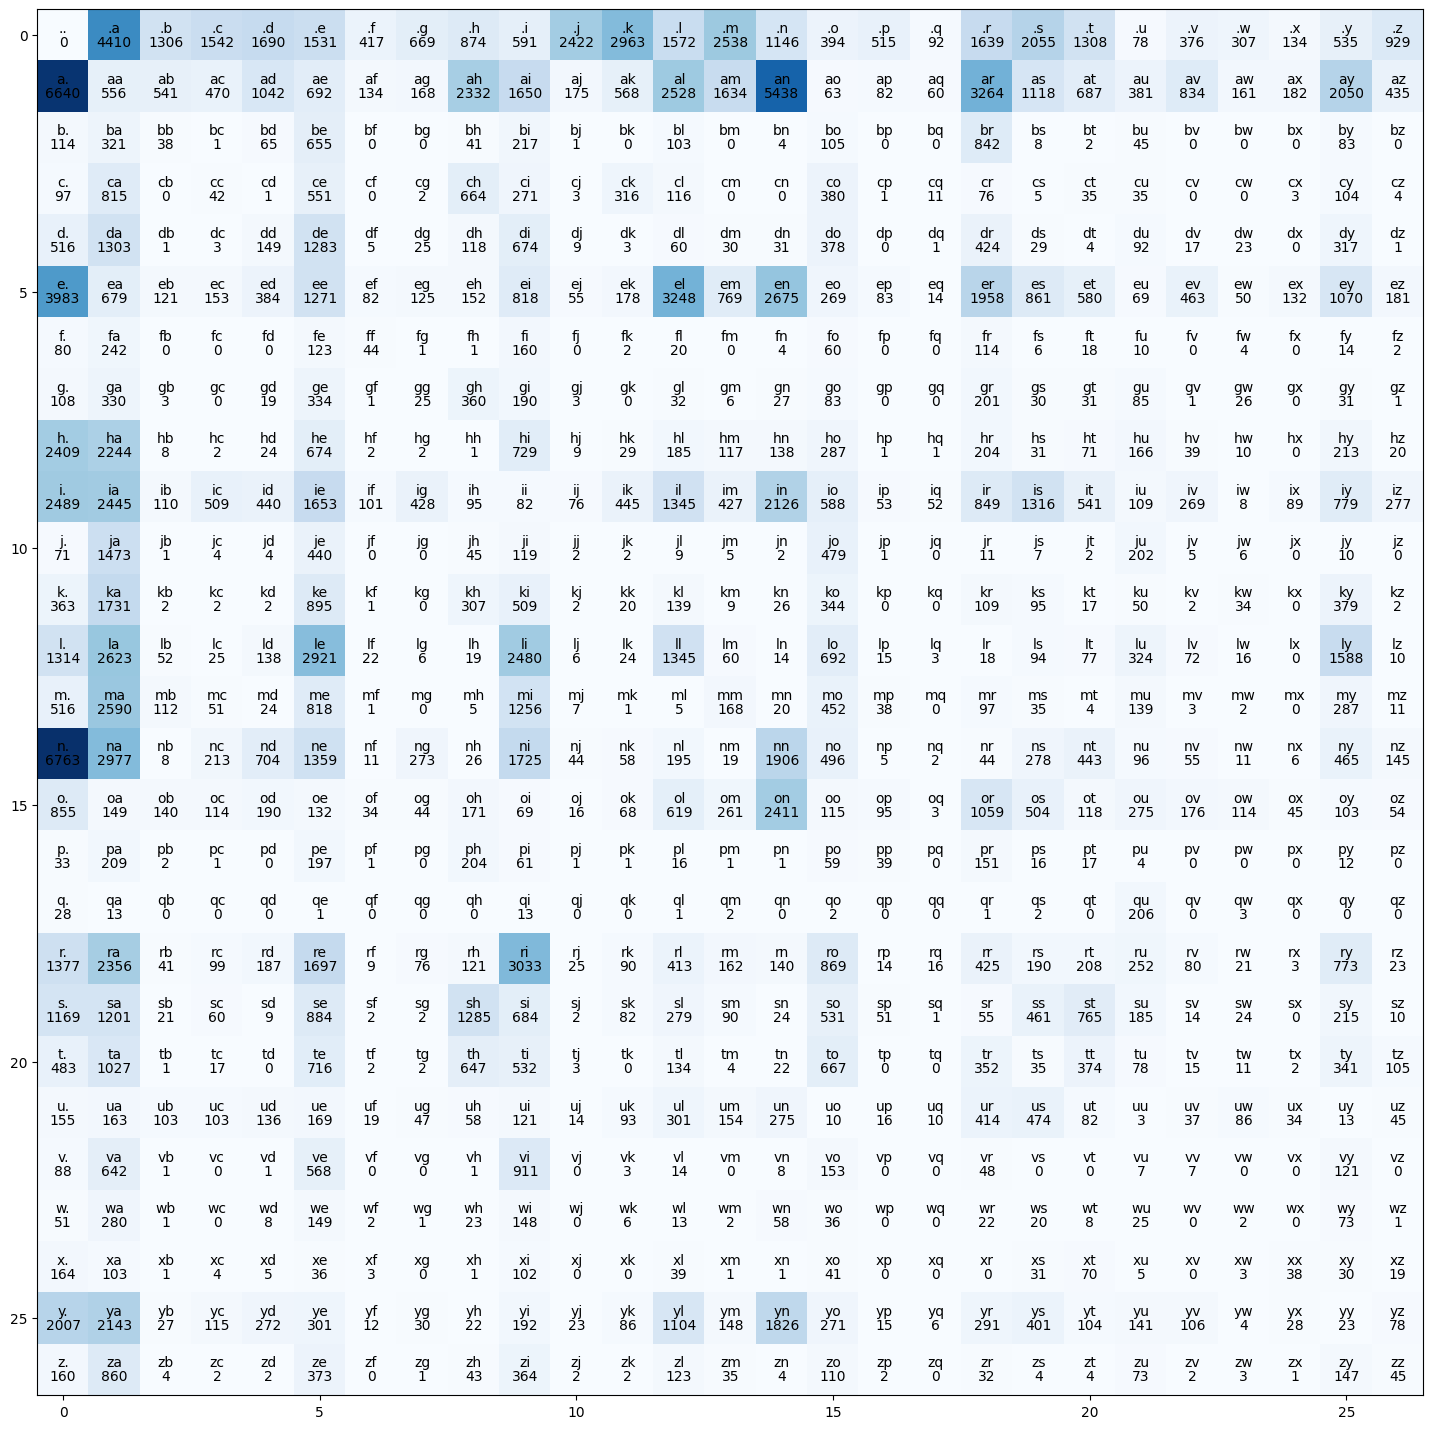

In [33]:
# visualize bigrams counts
plt.figure(figsize=(18, 18))
plt.imshow(bigrams_count, cmap='Blues')

for i in range(CHAR_COUNTS):
    for j in range(CHAR_COUNTS):
        s = itos[i] + itos[j]
        plt.text(j, i, s, ha='center', va='bottom')
        plt.text(j, i, bigrams_count[i, j].item(), ha='center', va='top')

In [34]:
# calculate probability distribution 
probabilities = (bigrams_count + 1).float() # +1 for smoothing the model elmenating any zero pobability for bigrams
probabilities /= probabilities.sum(1, keepdim=True)

In [37]:
gen = torch.Generator().manual_seed(42)

for i in range(100):
    out = []
    ix = 0
    while True:
        p = probabilities[ix]
        ix = torch.multinomial(
            p,
            num_samples=1,
            replacement=True,
            generator=gen,
        ).item()
        out.append(itos[ix])

        if ix == 0: # '.' end of the name
            break

    print(''.join(out))        

anugeenvi.
s.
mabian.
dan.
stan.
silaylelaremah.
li.
le.
epiachalen.
diza.
k.
ach.
jondry.
kanla.
miqulynaya.
visigea.
zalamitiare.
phalimasotal.
selaro.
dgharoni.
n.
anncrrigh.
dyn.
sor.
payiewo.
liljahm.
fri.
bradon.
an.
kyok.
feliavaham.
anone.
brral.
cho.
t.
damayanel.
ritaha.
iriatla.
ka.
mouchaame.
josky.
loraachan.
mooriaya.
hluli.
b.
th.
lykamiseysh.
endh.
n.
kee.
enoniahilln.
backvrselagrtol.
mc.
jana.
dan.
cakiahnynvya.
fag.
lolun.
ssahikig.
ann.
stila.
t.
juns.
ah.
ckayn.
aiah.
dre.
onizadrinisladahryn.
n.
mina.
den.
faxinnacobeshela.
li.
ja.
apedhte.
jan.
ailehale.
sennosem.
itin.
jeveadialella.
a.
aer.
rei.
anamonni.
hin.
nalefeieelen.
wthleyukalanor.
prratoverrelyzajeah.
a.
ane.
nyeytaliss.
shaijen.
ceelanetaniylye.
wi.
ysan.
jeniubrin.
a.
ynnihazepaleiveiquexili.
darn.
y.
